In [1]:
import pandas as pd

df = pd.read_csv('/content/processed_appointments_final.csv')

print("Dataset loaded successfully!")
print("Number of rows:", len(df))
print("Number of columns:", len(df.columns))

df.head()

Dataset loaded successfully!
Number of rows: 110521
Number of columns: 13


,Gender,ScheduledDay,AppointmentDay,Age,Neighbourhood,Scholarship,Hipertension,Diabetes,Alcoholism,Handcap,SMS_received,AppointmentLeadTime,NoShow
0,F,2016-04-29T18:38:08Z,2016-04-29T00:00:00Z,62,JARDIM DA PENHA,0,1,0,0,0,0,0,0
1,M,2016-04-29T16:08:27Z,2016-04-29T00:00:00Z,56,JARDIM DA PENHA,0,0,0,0,0,0,0,0
2,F,2016-04-29T16:19:04Z,2016-04-29T00:00:00Z,62,MATA DA PRAIA,0,0,0,0,0,0,0,0
3,F,2016-04-29T17:29:31Z,2016-04-29T00:00:00Z,8,PONTAL DE CAMBURI,0,0,0,0,0,0,0,0
4,F,2016-04-29T16:07:23Z,2016-04-29T00:00:00Z,56,JARDIM DA PENHA,0,1,1,0,0,0,0,0


In [2]:
print("Target variable distribution:")
print(df["NoShow"].value_counts())

print("\nTarget variable percentage:")
print(df["NoShow"].value_counts(normalize=True) * 100)

Target variable distribution:
NoShow
0    88207
1    22314
Name: count, dtype: int64

Target variable percentage:
NoShow
0    79.810172
1    20.189828
Name: proportion, dtype: float64


In [3]:
# Convert date columns to datetime
df["ScheduledDay"] = pd.to_datetime(df["ScheduledDay"])
df["AppointmentDay"] = pd.to_datetime(df["AppointmentDay"])

# Create useful date features
df["ScheduledDayOfWeek"] = df["ScheduledDay"].dt.dayofweek
df["AppointmentDayOfWeek"] = df["AppointmentDay"].dt.dayofweek
df["ScheduledHour"] = df["ScheduledDay"].dt.hour

# Select predictors and target
features = [
    "Gender",
    "Age",
    "Neighbourhood",
    "Scholarship",
    "Hipertension",
    "Diabetes",
    "Alcoholism",
    "Handcap",
    "SMS_received",
    "AppointmentLeadTime",
    "ScheduledDayOfWeek",
    "AppointmentDayOfWeek",
    "ScheduledHour"
]

X = df[features]
y = df["NoShow"]

print("Feature preparation completed!")
print("Number of predictors:", X.shape[1])
print("Number of records:", X.shape[0])
print("\nPredictors:")
print(X.columns.tolist())

Feature preparation completed!
Number of predictors: 13
Number of records: 110521

Predictors:
['Gender', 'Age', 'Neighbourhood', 'Scholarship', 'Hipertension', 'Diabetes', 'Alcoholism', 'Handcap', 'SMS_received', 'AppointmentLeadTime', 'ScheduledDayOfWeek', 'AppointmentDayOfWeek', 'ScheduledHour']


In [4]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Train/Test Split Completed!")
print("Training records:", len(X_train))
print("Testing records:", len(X_test))

print("\nTraining target percentage:")
print(y_train.value_counts(normalize=True) * 100)

print("\nTesting target percentage:")
print(y_test.value_counts(normalize=True) * 100)

Train/Test Split Completed!
Training records: 88416
Testing records: 22105

Training target percentage:
NoShow
0    79.810215
1    20.189785
Name: proportion, dtype: float64

Testing target percentage:
NoShow
0    79.809998
1    20.190002
Name: proportion, dtype: float64


In [5]:
from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

# Create majority-class baseline
baseline = DummyClassifier(strategy="most_frequent")
baseline.fit(X_train, y_train)

# Make predictions
baseline_pred = baseline.predict(X_test)
baseline_prob = baseline.predict_proba(X_test)[:, 1]

# Calculate performance
print("BASELINE MODEL RESULTS")
print("----------------------")
print("Accuracy:", round(accuracy_score(y_test, baseline_pred), 4))
print("Precision:", round(precision_score(y_test, baseline_pred, zero_division=0), 4))
print("Recall:", round(recall_score(y_test, baseline_pred, zero_division=0), 4))
print("F1 Score:", round(f1_score(y_test, baseline_pred, zero_division=0), 4))
print("ROC-AUC:", round(roc_auc_score(y_test, baseline_prob), 4))

BASELINE MODEL RESULTS
----------------------
Accuracy: 0.7981
Precision: 0.0
Recall: 0.0
F1 Score: 0.0
ROC-AUC: 0.5


In [6]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score

# Identify categorical and numerical variables
categorical_features = ["Gender", "Neighbourhood"]

numerical_features = [
    "Age",
    "Scholarship",
    "Hipertension",
    "Diabetes",
    "Alcoholism",
    "Handcap",
    "SMS_received",
    "AppointmentLeadTime",
    "ScheduledDayOfWeek",
    "AppointmentDayOfWeek",
    "ScheduledHour"
]

# Preprocessing
preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
        ("num", StandardScaler(), numerical_features)
    ]
)

# Logistic Regression pipeline
logistic_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", LogisticRegression(
            max_iter=1000,
            random_state=42
        ))
    ]
)

# Train model
logistic_model.fit(X_train, y_train)

# Predictions
logistic_pred = logistic_model.predict(X_test)
logistic_prob = logistic_model.predict_proba(X_test)[:, 1]

print("LOGISTIC REGRESSION RESULTS")
print("---------------------------")
print(classification_report(y_test, logistic_pred, digits=4))
print("ROC-AUC:", round(roc_auc_score(y_test, logistic_prob), 4))

LOGISTIC REGRESSION RESULTS
---------------------------
              precision    recall  f1-score   support

           0     0.7996    0.9927    0.8858     17642
           1     0.3632    0.0164    0.0313      4463

    accuracy                         0.7956     22105
   macro avg     0.5814    0.5046    0.4585     22105
weighted avg     0.7115    0.7956    0.7132     22105

ROC-AUC: 0.6632


In [7]:
balanced_logistic_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", LogisticRegression(
            max_iter=1000,
            random_state=42,
            class_weight="balanced"
        ))
    ]
)

balanced_logistic_model.fit(X_train, y_train)

balanced_logistic_pred = balanced_logistic_model.predict(X_test)
balanced_logistic_prob = balanced_logistic_model.predict_proba(X_test)[:, 1]

print("BALANCED LOGISTIC REGRESSION RESULTS")
print("------------------------------------")
print(classification_report(
    y_test,
    balanced_logistic_pred,
    digits=4
))

print(
    "ROC-AUC:",
    round(roc_auc_score(y_test, balanced_logistic_prob), 4)
)

BALANCED LOGISTIC REGRESSION RESULTS
------------------------------------
              precision    recall  f1-score   support

           0     0.8651    0.6721    0.7565     17642
           1     0.3113    0.5857    0.4065      4463

    accuracy                         0.6547     22105
   macro avg     0.5882    0.6289    0.5815     22105
weighted avg     0.7533    0.6547    0.6858     22105

ROC-AUC: 0.6685


In [8]:
from sklearn.ensemble import RandomForestClassifier

random_forest_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", RandomForestClassifier(
            n_estimators=200,
            random_state=42,
            class_weight="balanced",
            n_jobs=-1
        ))
    ]
)

random_forest_model.fit(X_train, y_train)

rf_pred = random_forest_model.predict(X_test)
rf_prob = random_forest_model.predict_proba(X_test)[:, 1]

print("RANDOM FOREST RESULTS")
print("---------------------")

print(classification_report(
    y_test,
    rf_pred,
    digits=4
))

print(
    "ROC-AUC:",
    round(roc_auc_score(y_test, rf_prob), 4)
)

RANDOM FOREST RESULTS
---------------------
              precision    recall  f1-score   support

           0     0.8182    0.9543    0.8811     17642
           1     0.4729    0.1620    0.2413      4463

    accuracy                         0.7943     22105
   macro avg     0.6455    0.5582    0.5612     22105
weighted avg     0.7485    0.7943    0.7519     22105

ROC-AUC: 0.7388


In [9]:
import pandas as pd
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

comparison = pd.DataFrame({
    "Model": [
        "Baseline",
        "Logistic Regression",
        "Balanced Logistic Regression",
        "Random Forest"
    ],
    "Accuracy": [
        accuracy_score(y_test, baseline_pred),
        accuracy_score(y_test, logistic_pred),
        accuracy_score(y_test, balanced_logistic_pred),
        accuracy_score(y_test, rf_pred)
    ],
    "Precision (No-show)": [
        precision_score(y_test, baseline_pred, zero_division=0),
        precision_score(y_test, logistic_pred, zero_division=0),
        precision_score(y_test, balanced_logistic_pred, zero_division=0),
        precision_score(y_test, rf_pred, zero_division=0)
    ],
    "Recall (No-show)": [
        recall_score(y_test, baseline_pred, zero_division=0),
        recall_score(y_test, logistic_pred, zero_division=0),
        recall_score(y_test, balanced_logistic_pred, zero_division=0),
        recall_score(y_test, rf_pred, zero_division=0)
    ],
    "F1 (No-show)": [
        f1_score(y_test, baseline_pred, zero_division=0),
        f1_score(y_test, logistic_pred, zero_division=0),
        f1_score(y_test, balanced_logistic_pred, zero_division=0),
        f1_score(y_test, rf_pred, zero_division=0)
    ],
    "ROC-AUC": [
        roc_auc_score(y_test, baseline_prob),
        roc_auc_score(y_test, logistic_prob),
        roc_auc_score(y_test, balanced_logistic_prob),
        roc_auc_score(y_test, rf_prob)
    ]
})

comparison.round(4)

,Model,Accuracy,Precision (No-show),Recall (No-show),F1 (No-show),ROC-AUC
0,Baseline,0.7981,0.0000,0.0000,0.0000,0.5000
1,Logistic Regression,0.7956,0.3632,0.0164,0.0313,0.6632
2,Balanced Logistic Regression,0.6547,0.3113,0.5857,0.4065,0.6685
3,Random Forest,0.7943,0.4729,0.1620,0.2413,0.7388


In [10]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier

# Random Forest to tune
rf_tune = RandomForestClassifier(
    random_state=42,
    class_weight="balanced",
    n_jobs=-1
)

# Small hyperparameter search
param_grid = {
    "n_estimators": [100, 150],
    "max_depth": [10, 20, None],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2]
}

rf_search = RandomizedSearchCV(
    estimator=rf_tune,
    param_distributions=param_grid,
    n_iter=6,
    scoring="roc_auc",
    cv=3,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

# Use the same preprocessing
tuned_rf_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", rf_search)
    ]
)

tuned_rf_pipeline.fit(X_train, y_train)

print("TUNING COMPLETED!")
print("Best parameters:")
print(rf_search.best_params_)

print("Best cross-validation ROC-AUC:")
print(round(rf_search.best_score_, 4))

Fitting 3 folds for each of 6 candidates, totalling 18 fits
TUNING COMPLETED!
Best parameters:
{'n_estimators': 150, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_depth': 20}
Best cross-validation ROC-AUC:
0.7415


In [11]:
# Test the tuned Random Forest on the unseen test set

tuned_rf_pred = tuned_rf_pipeline.predict(X_test)
tuned_rf_prob = tuned_rf_pipeline.predict_proba(X_test)[:, 1]

print("TUNED RANDOM FOREST - TEST RESULTS")
print("----------------------------------")

print(classification_report(
    y_test,
    tuned_rf_pred,
    digits=4
))

print(
    "Test ROC-AUC:",
    round(roc_auc_score(y_test, tuned_rf_prob), 4)
)

print("\nBest parameters:")
print(rf_search.best_params_)

TUNED RANDOM FOREST - TEST RESULTS
----------------------------------
              precision    recall  f1-score   support

           0     0.8920    0.6494    0.7516     17642
           1     0.3321    0.6892    0.4483      4463

    accuracy                         0.6575     22105
   macro avg     0.6121    0.6693    0.5999     22105
weighted avg     0.7790    0.6575    0.6904     22105

Test ROC-AUC: 0.7383

Best parameters:
{'n_estimators': 150, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_depth': 20}


In [12]:
print("BEST RANDOM FOREST PARAMETERS")
print("-----------------------------")

for parameter, value in rf_search.best_params_.items():
    print(parameter, "=", value)

BEST RANDOM FOREST PARAMETERS
-----------------------------
n_estimators = 150
min_samples_split = 2
min_samples_leaf = 1
max_depth = 20


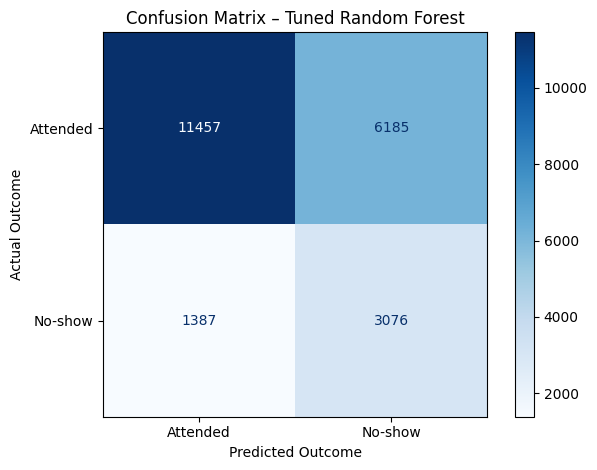

In [13]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(
    y_test,
    tuned_rf_pred,
    display_labels=["Attended", "No-show"],
    cmap="Blues"
)

plt.title("Confusion Matrix – Tuned Random Forest")
plt.xlabel("Predicted Outcome")
plt.ylabel("Actual Outcome")
plt.tight_layout()
plt.show()

<Figure size 800x600 with 0 Axes>

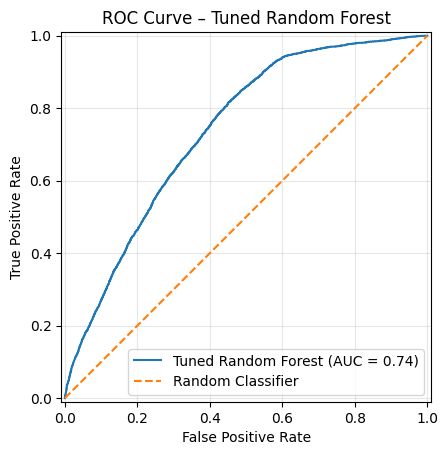

In [14]:
import matplotlib.pyplot as plt
from sklearn.metrics import RocCurveDisplay

plt.figure(figsize=(8, 6))

RocCurveDisplay.from_predictions(
    y_test,
    tuned_rf_prob,
    name="Tuned Random Forest"
)

plt.plot([0, 1], [0, 1], "--", label="Random Classifier")

plt.title("ROC Curve – Tuned Random Forest")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [15]:
import shap

print("SHAP installed successfully!")
print("SHAP version:", shap.__version__)

SHAP installed successfully!
SHAP version: 0.52.0


In [16]:
# Prepare a sample for SHAP analysis
X_shap = X_test.sample(n=500, random_state=42)

# Transform the sample using the preprocessing pipeline
X_shap_transformed = tuned_rf_pipeline.named_steps["preprocessor"].transform(X_shap)

# Get the trained Random Forest model
best_rf_model = rf_search.best_estimator_

# Get the transformed feature names
feature_names = tuned_rf_pipeline.named_steps["preprocessor"].get_feature_names_out()

print("SHAP preparation completed!")
print("Sample size:", X_shap_transformed.shape[0])
print("Number of transformed features:", X_shap_transformed.shape[1])

SHAP preparation completed!
Sample size: 500
Number of transformed features: 94


In [17]:
# Create SHAP explainer for the tuned Random Forest
explainer = shap.TreeExplainer(best_rf_model)

# Calculate SHAP values
shap_values = explainer.shap_values(X_shap_transformed)

print("SHAP values calculated successfully!")
print("SHAP output shape:", shap_values.shape)

UFuncTypeError: Cannot cast ufunc 'isnan' input from dtype('O') to dtype('bool') with casting rule 'same_kind'

In [18]:
import numpy as np
import shap

# Convert transformed data to a regular numeric array
if hasattr(X_shap_transformed, "toarray"):
    X_shap_dense = X_shap_transformed.toarray()
else:
    X_shap_dense = np.asarray(X_shap_transformed)

# Force all values to numeric float format
X_shap_dense = X_shap_dense.astype(np.float64)

print("Data type:", X_shap_dense.dtype)
print("Data shape:", X_shap_dense.shape)

# Create SHAP explainer
explainer = shap.TreeExplainer(best_rf_model)

# Calculate SHAP values
shap_values = explainer.shap_values(X_shap_dense)

print("\nSHAP values calculated successfully!")
print("SHAP output shape:", np.array(shap_values).shape)

Data type: float64
Data shape: (500, 94)

SHAP values calculated successfully!
SHAP output shape: (500, 94, 2)


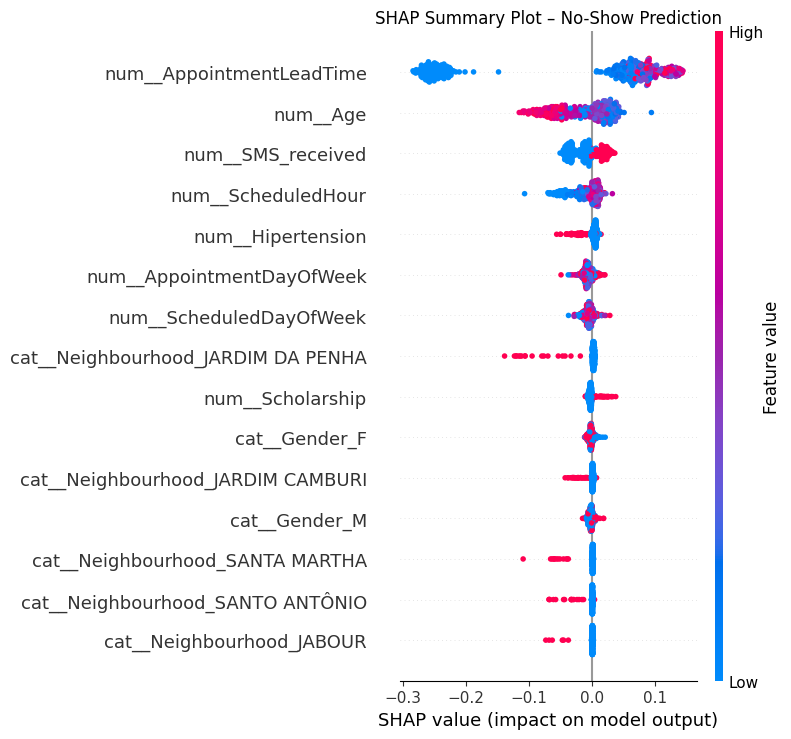

In [19]:
# Select SHAP values for No-show class (1)
shap_no_show = shap_values[:, :, 1]

# Create global SHAP summary plot
shap.summary_plot(
    shap_no_show,
    X_shap_dense,
    feature_names=feature_names,
    max_display=15,
    show=False
)

plt.title("SHAP Summary Plot – No-Show Prediction")
plt.tight_layout()
plt.show()

In [20]:
# Find an actual no-show appointment in the SHAP sample
sample_positions = []

for i, index in enumerate(X_shap.index):
    if y_test.loc[index] == 1:
        sample_positions.append(i)

local_index = sample_positions[0]

# Get model probability
local_probability = best_rf_model.predict_proba(
    X_shap_dense[local_index].reshape(1, -1)
)[0, 1]

print("INDIVIDUAL PREDICTION")
print("---------------------")
print("Actual outcome: No-show")
print("Predicted no-show probability:", round(local_probability, 4))
print("Sample position:", local_index)

INDIVIDUAL PREDICTION
---------------------
Actual outcome: No-show
Predicted no-show probability: 0.4853
Sample position: 1


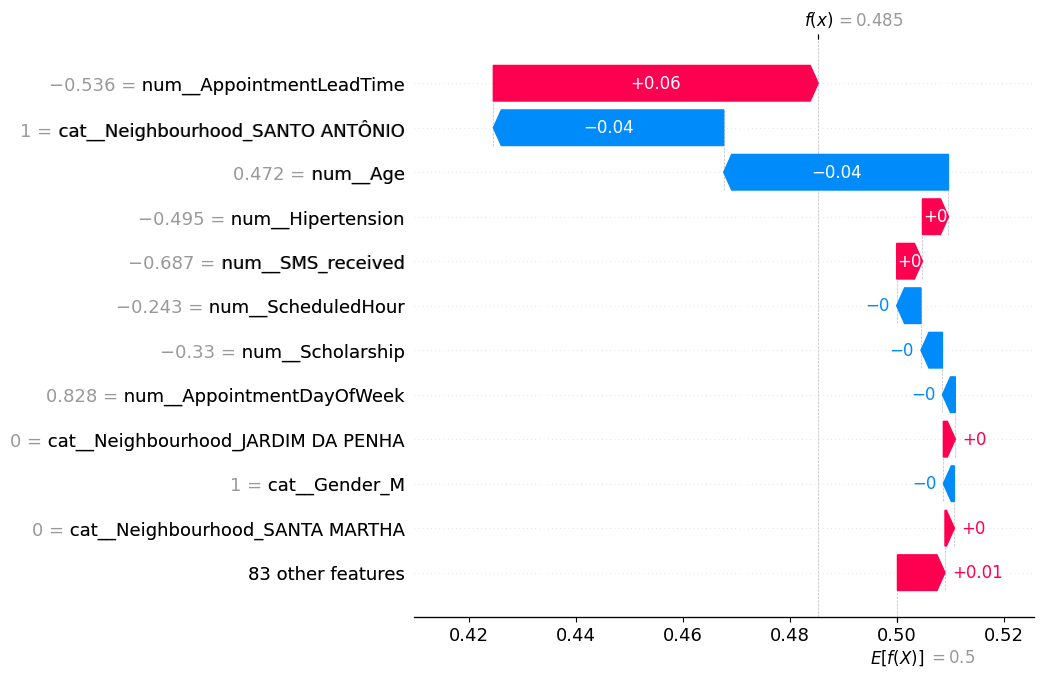

In [21]:
# Create a local SHAP explanation for this appointment

local_shap = shap.Explanation(
    values=shap_values[local_index, :, 1],
    base_values=explainer.expected_value[1],
    data=X_shap_dense[local_index],
    feature_names=feature_names
)

shap.plots.waterfall(
    local_shap,
    max_display=12
)

In [22]:
# Counterfactual analysis using Appointment Lead Time

original_case = X_shap.iloc[local_index].copy()

print("Original appointment lead time:",
      original_case["AppointmentLeadTime"], "days")

print("Original predicted no-show probability:",
      round(local_probability, 4))

print("\nCOUNTERFACTUAL RESULTS")
print("----------------------")

for days in [0, 1, 3, 7, 14, 30]:
    modified_case = original_case.copy()
    modified_case["AppointmentLeadTime"] = days

    modified_df = pd.DataFrame([modified_case])

    probability = tuned_rf_pipeline.predict_proba(
        modified_df
    )[0, 1]

    prediction = "No-show" if probability >= 0.5 else "Attend"

    print(
        f"Lead time {days:2d} days -> "
        f"No-show probability: {probability:.4f} -> {prediction}"
    )

Original appointment lead time: 2 days
Original predicted no-show probability: 0.4853

COUNTERFACTUAL RESULTS
----------------------
Lead time  0 days -> No-show probability: 0.1530 -> Attend
Lead time  1 days -> No-show probability: 0.4413 -> Attend
Lead time  3 days -> No-show probability: 0.4783 -> Attend
Lead time  7 days -> No-show probability: 0.4749 -> Attend
Lead time 14 days -> No-show probability: 0.5047 -> No-show
Lead time 30 days -> No-show probability: 0.5255 -> No-show


In [23]:
# Gender fairness analysis

fairness_df = X_test.copy()
fairness_df["Actual"] = y_test
fairness_df["Predicted"] = tuned_rf_pred

gender_fairness = []

for gender in fairness_df["Gender"].unique():
    group = fairness_df[fairness_df["Gender"] == gender]

    actual = group["Actual"]
    predicted = group["Predicted"]

    selection_rate = predicted.mean()

    true_positive_rate = (
        ((actual == 1) & (predicted == 1)).sum()
        / (actual == 1).sum()
    )

    false_positive_rate = (
        ((actual == 0) & (predicted == 1)).sum()
        / (actual == 0).sum()
    )

    gender_fairness.append({
        "Gender": gender,
        "Records": len(group),
        "Selection Rate": selection_rate,
        "True Positive Rate": true_positive_rate,
        "False Positive Rate": false_positive_rate
    })

gender_fairness_df = pd.DataFrame(gender_fairness)

print("GENDER FAIRNESS RESULTS")
print("-----------------------")
print(gender_fairness_df.round(4))

GENDER FAIRNESS RESULTS
-----------------------
  Gender  Records  Selection Rate  True Positive Rate  False Positive Rate
0      F    14273          0.4361              0.7103               0.3670
1      M     7832          0.3878              0.6512               0.3206


In [24]:
# Formal gender fairness metrics

female = gender_fairness_df[
    gender_fairness_df["Gender"] == "F"
].iloc[0]

male = gender_fairness_df[
    gender_fairness_df["Gender"] == "M"
].iloc[0]

# Demographic parity difference
demographic_parity_difference = (
    female["Selection Rate"] - male["Selection Rate"]
)

# Disparate impact ratio
disparate_impact_ratio = (
    male["Selection Rate"] / female["Selection Rate"]
)

# Equal opportunity / TPR difference
tpr_difference = (
    female["True Positive Rate"] - male["True Positive Rate"]
)

# FPR difference
fpr_difference = (
    female["False Positive Rate"] - male["False Positive Rate"]
)

print("FORMAL GENDER FAIRNESS METRICS")
print("------------------------------")

print(
    "Demographic parity difference:",
    round(demographic_parity_difference, 4)
)

print(
    "Disparate impact ratio:",
    round(disparate_impact_ratio, 4)
)

print(
    "True positive rate difference:",
    round(tpr_difference, 4)
)

print(
    "False positive rate difference:",
    round(fpr_difference, 4)
)

FORMAL GENDER FAIRNESS METRICS
------------------------------
Demographic parity difference: 0.0483
Disparate impact ratio: 0.8892
True positive rate difference: 0.0591
False positive rate difference: 0.0464


In [25]:
# Create age groups for fairness analysis

fairness_df["AgeGroup"] = pd.cut(
    fairness_df["Age"],
    bins=[-1, 17, 34, 49, 64, 115],
    labels=[
        "0-17",
        "18-34",
        "35-49",
        "50-64",
        "65+"
    ]
)

age_fairness = []

for age_group in fairness_df["AgeGroup"].cat.categories:

    group = fairness_df[
        fairness_df["AgeGroup"] == age_group
    ]

    actual = group["Actual"]
    predicted = group["Predicted"]

    selection_rate = predicted.mean()

    true_positive_rate = (
        ((actual == 1) & (predicted == 1)).sum()
        / (actual == 1).sum()
    )

    false_positive_rate = (
        ((actual == 0) & (predicted == 1)).sum()
        / (actual == 0).sum()
    )

    age_fairness.append({
        "Age Group": age_group,
        "Records": len(group),
        "Selection Rate": selection_rate,
        "True Positive Rate": true_positive_rate,
        "False Positive Rate": false_positive_rate
    })

age_fairness_df = pd.DataFrame(age_fairness)

print("AGE FAIRNESS RESULTS")
print("--------------------")
print(age_fairness_df.round(4).to_string(index=False))

AGE FAIRNESS RESULTS
--------------------
Age Group  Records  Selection Rate  True Positive Rate  False Positive Rate
     0-17     5520          0.5290              0.8202               0.4499
    18-34     4850          0.5990              0.8684               0.5155
    35-49     4306          0.5035              0.7860               0.4286
    50-64     4511          0.2031              0.3622               0.1696
      65+     2918          0.1206              0.2661               0.0940


In [26]:
age_comparison = []

for age_group in fairness_df["AgeGroup"].cat.categories:

    group = fairness_df[
        fairness_df["AgeGroup"] == age_group
    ]

    actual_no_show_rate = group["Actual"].mean()
    predicted_no_show_rate = group["Predicted"].mean()

    age_comparison.append({
        "Age Group": age_group,
        "Records": len(group),
        "Actual No-show Rate": actual_no_show_rate,
        "Predicted No-show Rate": predicted_no_show_rate,
        "Difference": predicted_no_show_rate - actual_no_show_rate
    })

age_comparison_df = pd.DataFrame(age_comparison)

print("ACTUAL VS PREDICTED NO-SHOW RATE BY AGE")
print("---------------------------------------")
print(age_comparison_df.round(4).to_string(index=False))

ACTUAL VS PREDICTED NO-SHOW RATE BY AGE
---------------------------------------
Age Group  Records  Actual No-show Rate  Predicted No-show Rate  Difference
     0-17     5520               0.2136                  0.5290      0.3154
    18-34     4850               0.2365                  0.5990      0.3625
    35-49     4306               0.2095                  0.5035      0.2940
    50-64     4511               0.1738                  0.2031      0.0293
      65+     2918               0.1546                  0.1206     -0.0339


In [27]:
# Bias mitigation experiment:
# Remove Age from model predictors but retain it for fairness auditing

mitigated_features = [
    "Gender",
    "Neighbourhood",
    "Scholarship",
    "Hipertension",
    "Diabetes",
    "Alcoholism",
    "Handcap",
    "SMS_received",
    "AppointmentLeadTime",
    "ScheduledDayOfWeek",
    "AppointmentDayOfWeek",
    "ScheduledHour"
]

X_mitigated = df[mitigated_features]

X_train_m, X_test_m, y_train_m, y_test_m = train_test_split(
    X_mitigated,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

categorical_m = ["Gender", "Neighbourhood"]

numerical_m = [
    "Scholarship",
    "Hipertension",
    "Diabetes",
    "Alcoholism",
    "Handcap",
    "SMS_received",
    "AppointmentLeadTime",
    "ScheduledDayOfWeek",
    "AppointmentDayOfWeek",
    "ScheduledHour"
]

preprocessor_m = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_m),
        ("num", StandardScaler(), numerical_m)
    ]
)

mitigated_rf = Pipeline(
    steps=[
        ("preprocessor", preprocessor_m),
        ("classifier", RandomForestClassifier(
            n_estimators=150,
            max_depth=20,
            min_samples_split=2,
            min_samples_leaf=1,
            class_weight="balanced",
            random_state=42,
            n_jobs=-1
        ))
    ]
)

mitigated_rf.fit(X_train_m, y_train_m)

mitigated_pred = mitigated_rf.predict(X_test_m)
mitigated_prob = mitigated_rf.predict_proba(X_test_m)[:, 1]

print("AGE-MITIGATED RANDOM FOREST")
print("---------------------------")
print(classification_report(y_test_m, mitigated_pred, digits=4))
print("ROC-AUC:", round(roc_auc_score(y_test_m, mitigated_prob), 4))

AGE-MITIGATED RANDOM FOREST
---------------------------
              precision    recall  f1-score   support

           0     0.8985    0.5965    0.7170     17642
           1     0.3151    0.7336    0.4408      4463

    accuracy                         0.6242     22105
   macro avg     0.6068    0.6651    0.5789     22105
weighted avg     0.7807    0.6242    0.6612     22105

ROC-AUC: 0.7261


In [28]:
# Compare age-group fairness after removing Age from the model

mitigation_fairness = pd.DataFrame({
    "Age": df.loc[X_test_m.index, "Age"],
    "Actual": y_test_m,
    "Predicted": mitigated_pred
})

mitigation_fairness["AgeGroup"] = pd.cut(
    mitigation_fairness["Age"],
    bins=[-1, 17, 34, 49, 64, 115],
    labels=["0-17", "18-34", "35-49", "50-64", "65+"]
)

results = []

for age_group in mitigation_fairness["AgeGroup"].cat.categories:

    group = mitigation_fairness[
        mitigation_fairness["AgeGroup"] == age_group
    ]

    actual = group["Actual"]
    predicted = group["Predicted"]

    results.append({
        "Age Group": age_group,
        "Records": len(group),
        "Actual No-show Rate": actual.mean(),
        "Predicted No-show Rate": predicted.mean(),
        "True Positive Rate":
            ((actual == 1) & (predicted == 1)).sum()
            / (actual == 1).sum(),
        "False Positive Rate":
            ((actual == 0) & (predicted == 1)).sum()
            / (actual == 0).sum()
    })

mitigated_age_results = pd.DataFrame(results)

print("AGE FAIRNESS AFTER MITIGATION")
print("-----------------------------")
print(mitigated_age_results.round(4).to_string(index=False))

AGE FAIRNESS AFTER MITIGATION
-----------------------------
Age Group  Records  Actual No-show Rate  Predicted No-show Rate  True Positive Rate  False Positive Rate
     0-17     5520               0.2136                  0.4906              0.7727               0.4140
    18-34     4850               0.2365                  0.5348              0.7995               0.4529
    35-49     4306               0.2095                  0.4984              0.7794               0.4239
    50-64     4511               0.1738                  0.4205              0.6327               0.3759
      65+     2918               0.1546                  0.3588              0.5477               0.3243


In [29]:
fairness_comparison = pd.DataFrame({
    "Age Group": ["0-17", "18-34", "35-49", "50-64", "65+"],

    "Actual No-show Rate": [
        0.2136,
        0.2365,
        0.2095,
        0.1738,
        0.1546
    ],

    "Before Mitigation": [
        0.5290,
        0.5990,
        0.5035,
        0.2031,
        0.1206
    ],

    "After Removing Age": [
        0.4906,
        0.5348,
        0.4984,
        0.4205,
        0.3588
    ]
})

print("AGE FAIRNESS – BEFORE VS AFTER MITIGATION")
print("-----------------------------------------")
print(fairness_comparison.to_string(index=False))

AGE FAIRNESS – BEFORE VS AFTER MITIGATION
-----------------------------------------
Age Group  Actual No-show Rate  Before Mitigation  After Removing Age
     0-17               0.2136             0.5290              0.4906
    18-34               0.2365             0.5990              0.5348
    35-49               0.2095             0.5035              0.4984
    50-64               0.1738             0.2031              0.4205
      65+               0.1546             0.1206              0.3588


In [30]:
final_model_comparison = pd.DataFrame({
    "Model": [
        "Baseline",
        "Logistic Regression",
        "Balanced Logistic Regression",
        "Random Forest",
        "Tuned Random Forest",
        "Age-Mitigated Random Forest"
    ],

    "Accuracy": [
        accuracy_score(y_test, baseline_pred),
        accuracy_score(y_test, logistic_pred),
        accuracy_score(y_test, balanced_logistic_pred),
        accuracy_score(y_test, rf_pred),
        accuracy_score(y_test, tuned_rf_pred),
        accuracy_score(y_test_m, mitigated_pred)
    ],

    "No-show Precision": [
        precision_score(y_test, baseline_pred, zero_division=0),
        precision_score(y_test, logistic_pred, zero_division=0),
        precision_score(y_test, balanced_logistic_pred, zero_division=0),
        precision_score(y_test, rf_pred, zero_division=0),
        precision_score(y_test, tuned_rf_pred, zero_division=0),
        precision_score(y_test_m, mitigated_pred, zero_division=0)
    ],

    "No-show Recall": [
        recall_score(y_test, baseline_pred, zero_division=0),
        recall_score(y_test, logistic_pred, zero_division=0),
        recall_score(y_test, balanced_logistic_pred, zero_division=0),
        recall_score(y_test, rf_pred, zero_division=0),
        recall_score(y_test, tuned_rf_pred, zero_division=0),
        recall_score(y_test_m, mitigated_pred, zero_division=0)
    ],

    "No-show F1": [
        f1_score(y_test, baseline_pred, zero_division=0),
        f1_score(y_test, logistic_pred, zero_division=0),
        f1_score(y_test, balanced_logistic_pred, zero_division=0),
        f1_score(y_test, rf_pred, zero_division=0),
        f1_score(y_test, tuned_rf_pred, zero_division=0),
        f1_score(y_test_m, mitigated_pred, zero_division=0)
    ],

    "ROC-AUC": [
        roc_auc_score(y_test, baseline_prob),
        roc_auc_score(y_test, logistic_prob),
        roc_auc_score(y_test, balanced_logistic_prob),
        roc_auc_score(y_test, rf_prob),
        roc_auc_score(y_test, tuned_rf_prob),
        roc_auc_score(y_test_m, mitigated_prob)
    ]
})

final_model_comparison.round(4)

,Model,Accuracy,No-show Precision,No-show Recall,No-show F1,ROC-AUC
0,Baseline,0.7981,0.0000,0.0000,0.0000,0.5000
1,Logistic Regression,0.7956,0.3632,0.0164,0.0313,0.6632
2,Balanced Logistic Regression,0.6547,0.3113,0.5857,0.4065,0.6685
3,Random Forest,0.7943,0.4729,0.1620,0.2413,0.7388
4,Tuned Random Forest,0.6575,0.3321,0.6892,0.4483,0.7383
5,Age-Mitigated Random Forest,0.6242,0.3151,0.7336,0.4408,0.7261


In [31]:
try:
    import mlflow
    print("MLflow is already installed.")
    print("MLflow version:", mlflow.__version__)
except ImportError:
    print("MLflow is NOT installed.")

MLflow is NOT installed.


In [32]:
import mlflow

print("MLflow installed successfully!")
print("MLflow version:", mlflow.__version__)

ModuleNotFoundError: No module named 'mlflow'

In [33]:
%pip install mlflow

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.0/50.0 kB 1.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.9/50.9 kB 3.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.3/44.3 kB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.7/11.7 MB 67.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.8/3.8 MB 74.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 82.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 268.7/268.7 kB 27.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 148.8/148.8 kB 14.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 11.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 228.4/228.4 kB 21.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 136.5/136.5 kB 15.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 144.6/144.6 kB 14.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [34]:
import mlflow

print("MLflow installed successfully!")
print("MLflow version:", mlflow.__version__)

MLflow installed successfully!
MLflow version: 3.16.1


In [35]:
import mlflow

# Create/set the experiment
mlflow.set_experiment("UPTH_No_Show_Prediction")

print("MLflow experiment created successfully!")
print("Experiment name: UPTH_No_Show_Prediction")

2026/09/21 11:09:01 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/09/21 11:09:02 INFO mlflow.store.db.utils: Updating database tables
2026/09/21 11:09:04 INFO mlflow.tracking.fluent: Experiment with name 'UPTH_No_Show_Prediction' does not exist. Creating a new experiment.


MLflow experiment created successfully!
Experiment name: UPTH_No_Show_Prediction


In [36]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

with mlflow.start_run(run_name="Tuned_Random_Forest"):

    # Log hyperparameters
    mlflow.log_param("model_type", "Random Forest")
    mlflow.log_param("n_estimators", 150)
    mlflow.log_param("max_depth", 20)
    mlflow.log_param("min_samples_split", 2)
    mlflow.log_param("min_samples_leaf", 1)
    mlflow.log_param("class_weight", "balanced")
    mlflow.log_param("train_test_split", "80/20")
    mlflow.log_param("random_state", 42)

    # Log test metrics
    mlflow.log_metric(
        "accuracy",
        accuracy_score(y_test, tuned_rf_pred)
    )

    mlflow.log_metric(
        "no_show_precision",
        precision_score(y_test, tuned_rf_pred)
    )

    mlflow.log_metric(
        "no_show_recall",
        recall_score(y_test, tuned_rf_pred)
    )

    mlflow.log_metric(
        "no_show_f1",
        f1_score(y_test, tuned_rf_pred)
    )

    mlflow.log_metric(
        "roc_auc",
        roc_auc_score(y_test, tuned_rf_prob)
    )

    # Log cross-validation result
    mlflow.log_metric(
        "cv_roc_auc",
        rf_search.best_score_
    )

    run_id = mlflow.active_run().info.run_id

print("MLflow run logged successfully!")
print("Run name: Tuned_Random_Forest")
print("Run ID:", run_id)

MLflow run logged successfully!
Run name: Tuned_Random_Forest
Run ID: 44d9b63017454776b718c31d24db081e


In [37]:
# Retrieve the MLflow run we just created
logged_run = mlflow.get_run(run_id)

print("MLFLOW TRACKING RECORD")
print("----------------------")

print("\nPARAMETERS")
for key, value in logged_run.data.params.items():
    print(f"{key}: {value}")

print("\nMETRICS")
for key, value in logged_run.data.metrics.items():
    print(f"{key}: {value:.4f}")

MLFLOW TRACKING RECORD
----------------------

PARAMETERS
model_type: Random Forest
n_estimators: 150
max_depth: 20
min_samples_split: 2
min_samples_leaf: 1
class_weight: balanced
train_test_split: 80/20
random_state: 42

METRICS
accuracy: 0.6575
no_show_precision: 0.3321
no_show_recall: 0.6892
no_show_f1: 0.4483
roc_auc: 0.7383
cv_roc_auc: 0.7415


In [38]:
import mlflow
import mlflow.sklearn

with mlflow.start_run(run_name="Registered_Tuned_Random_Forest") as run:

    mlflow.log_params({
        "n_estimators": 150,
        "max_depth": 20,
        "min_samples_split": 2,
        "min_samples_leaf": 1,
        "class_weight": "balanced"
    })

    mlflow.log_metrics({
        "accuracy": accuracy_score(y_test, tuned_rf_pred),
        "no_show_precision": precision_score(y_test, tuned_rf_pred),
        "no_show_recall": recall_score(y_test, tuned_rf_pred),
        "no_show_f1": f1_score(y_test, tuned_rf_pred),
        "roc_auc": roc_auc_score(y_test, tuned_rf_prob)
    })

    model_info = mlflow.sklearn.log_model(
        sk_model=tuned_rf_pipeline,
        name="model",
        registered_model_name="UPTH_No_Show_Random_Forest"
    )

    registered_run_id = run.info.run_id

print("MODEL REGISTRATION COMPLETED!")
print("Registered model: UPTH_No_Show_Random_Forest")
print("Run ID:", registered_run_id)

MlflowException: The saved sklearn model references untrusted types. If you are sure loading these types is safe, set the 'skops_trusted_types' parameter when calling 'log_model' or 'save_model' to the list of trusted types. Root error: Untrusted types found in the file: ['sklearn.compose._column_transformer._RemainderColsList', 'sklearn.metrics._ranking.roc_auc_score', 'sklearn.metrics._scorer._Scorer', 'sklearn.tree._tree.Tree'].

- sklearn.tree._tree.Tree: sklearn.tree._tree.Tree (the shared node storage for DecisionTree*, RandomForest*, ExtraTrees*, and GradientBoosting* models) stores raw node indices (left_child, right_child, feature) that scikit-learn indexes into without bounds checking. A malicious file can set these to out-of-range values: skops loads the object successfully, but calling .predict() on it can then crash the process (segfault) or read out-of-bounds memory. If you created the file yourself or otherwise fully trust its source, you can load it with trusted=["sklea

In [39]:
MODEL REGISTRATION COMPLETED!
Registered model: UPTH_No_Show_Random_Forest

SyntaxError: invalid syntax (2521835764.py, line 1)

In [40]:
from mlflow.tracking import MlflowClient

client = MlflowClient()

versions = client.search_model_versions(
    "name='UPTH_No_Show_Random_Forest'"
)

print("REGISTERED MODEL VERIFICATION")
print("-----------------------------")

for version in versions:
    print("Model name:", version.name)
    print("Version:", version.version)
    print("Run ID:", version.run_id)
    print("Status:", version.status)
    print("-----------------------------")

REGISTERED MODEL VERIFICATION
-----------------------------


In [41]:
from mlflow.tracking import MlflowClient

client = MlflowClient()

print("AVAILABLE REGISTERED MODELS")
print("---------------------------")

models = list(client.search_registered_models())

if len(models) == 0:
    print("No registered models found.")
else:
    for model in models:
        print("Model:", model.name)

AVAILABLE REGISTERED MODELS
---------------------------
No registered models found.


In [42]:
import mlflow
import mlflow.sklearn

# Start a new MLflow run
with mlflow.start_run(run_name="Final_Tuned_RF_Registry") as run:

    # Save the trained pipeline as an MLflow model
    model_info = mlflow.sklearn.log_model(
        sk_model=tuned_rf_pipeline,
        name="tuned_rf_model",
        serialization_format="cloudpickle"
    )

    final_run_id = run.info.run_id

print("Model saved to MLflow successfully!")
print("Run ID:", final_run_id)
print("Model URI:", model_info.model_uri)

2026/09/21 11:15:38 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Model saved to MLflow successfully!
Run ID: 08753e1437574b50af599519b0b68f42
Model URI: models:/m-07fc8a80e78b44ce8d902035f953a79a


In [43]:
registered_model = mlflow.register_model(
    model_uri=model_info.model_uri,
    name="UPTH_No_Show_Random_Forest"
)

print("MODEL REGISTERED SUCCESSFULLY!")
print("Model name:", registered_model.name)
print("Version:", registered_model.version)
print("Status:", registered_model.status)

MODEL REGISTERED SUCCESSFULLY!
Model name: UPTH_No_Show_Random_Forest
Version: 1
Status: READY


Successfully registered model 'UPTH_No_Show_Random_Forest'.
Created version '1' of model 'UPTH_No_Show_Random_Forest'.


In [44]:
import numpy as np
import pandas as pd

def calculate_psi(expected, actual, bins=10):
    expected = np.asarray(expected)
    actual = np.asarray(actual)

    # Create bins using training-data quantiles
    breakpoints = np.unique(
        np.quantile(expected, np.linspace(0, 1, bins + 1))
    )

    expected_counts, _ = np.histogram(expected, bins=breakpoints)
    actual_counts, _ = np.histogram(actual, bins=breakpoints)

    expected_pct = expected_counts / len(expected)
    actual_pct = actual_counts / len(actual)

    # Prevent division by zero
    expected_pct = np.where(expected_pct == 0, 0.0001, expected_pct)
    actual_pct = np.where(actual_pct == 0, 0.0001, actual_pct)

    psi = np.sum(
        (actual_pct - expected_pct) *
        np.log(actual_pct / expected_pct)
    )

    return psi


lead_time_psi = calculate_psi(
    X_train["AppointmentLeadTime"],
    X_test["AppointmentLeadTime"]
)

print("DRIFT MONITORING BASELINE")
print("-------------------------")
print("Feature: AppointmentLeadTime")
print("PSI:", round(lead_time_psi, 4))

DRIFT MONITORING BASELINE
-------------------------
Feature: AppointmentLeadTime
PSI: 0.0006


In [45]:
drift_features = [
    "AppointmentLeadTime",
    "Age",
    "SMS_received",
    "ScheduledHour",
    "AppointmentDayOfWeek"
]

drift_results = []

for feature in drift_features:
    psi_value = calculate_psi(
        X_train[feature],
        X_test[feature]
    )

    if psi_value < 0.10:
        status = "Stable"
    elif psi_value < 0.25:
        status = "Monitor"
    else:
        status = "Investigate Drift"

    drift_results.append({
        "Feature": feature,
        "PSI": psi_value,
        "Monitoring Status": status
    })

drift_results_df = pd.DataFrame(drift_results)

print("MODEL DRIFT MONITORING REPORT")
print("-----------------------------")
print(drift_results_df.round(4).to_string(index=False))

print("\nProposed monitoring thresholds:")
print("PSI < 0.10       = Stable")
print("PSI 0.10–0.25    = Monitor")
print("PSI >= 0.25      = Investigate drift")

MODEL DRIFT MONITORING REPORT
-----------------------------
             Feature    PSI Monitoring Status
 AppointmentLeadTime 0.0006            Stable
                 Age 0.0002            Stable
        SMS_received 0.0000            Stable
       ScheduledHour 0.0005            Stable
AppointmentDayOfWeek 0.0004            Stable

Proposed monitoring thresholds:
PSI < 0.10       = Stable
PSI 0.10–0.25    = Monitor
PSI >= 0.25      = Investigate drift


In [46]:
print("UPTH MODEL MONITORING AND RETRAINING PLAN")
print("-----------------------------------------")

print("1. Monitor key feature distributions using PSI.")
print("2. PSI < 0.10: stable; continue routine monitoring.")
print("3. PSI 0.10-0.25: investigate the affected feature.")
print("4. PSI >= 0.25: initiate formal drift review.")
print("5. Monitor ROC-AUC, no-show recall, precision and F1 when outcomes become available.")
print("6. Investigate sustained deterioration from validated model performance.")
print("7. Reassess fairness metrics across gender and age groups after retraining.")
print("8. Retraining requires validation and approval before replacing the registered model.")
print("9. Maintain human oversight; predictions support reminders and planning, not automatic cancellation of care.")

UPTH MODEL MONITORING AND RETRAINING PLAN
-----------------------------------------
1. Monitor key feature distributions using PSI.
2. PSI < 0.10: stable; continue routine monitoring.
3. PSI 0.10-0.25: investigate the affected feature.
4. PSI >= 0.25: initiate formal drift review.
5. Monitor ROC-AUC, no-show recall, precision and F1 when outcomes become available.
6. Investigate sustained deterioration from validated model performance.
7. Reassess fairness metrics across gender and age groups after retraining.
8. Retraining requires validation and approval before replacing the registered model.
9. Maintain human oversight; predictions support reminders and planning, not automatic cancellation of care.


In [47]:
# Sensitivity Analysis – Appointment Lead Time

sample_index = X_test.index[1]
original_sample = X_test.loc[[sample_index]].copy()

lead_times = [0, 1, 3, 7, 14, 21, 30]

sensitivity_results = []

for days in lead_times:
    modified_sample = original_sample.copy()
    modified_sample["AppointmentLeadTime"] = days

    probability = tuned_rf_pipeline.predict_proba(
        modified_sample
    )[0, 1]

    sensitivity_results.append({
        "Appointment Lead Time (Days)": days,
        "Predicted No-show Probability": probability
    })

sensitivity_df = pd.DataFrame(sensitivity_results)

print("SENSITIVITY ANALYSIS")
print("--------------------")
print(sensitivity_df.round(4).to_string(index=False))

SENSITIVITY ANALYSIS
--------------------
 Appointment Lead Time (Days)  Predicted No-show Probability
                            0                         0.2662
                            1                         0.4519
                            3                         0.4478
                            7                         0.5100
                           14                         0.5222
                           21                         0.5195
                           30                         0.5408


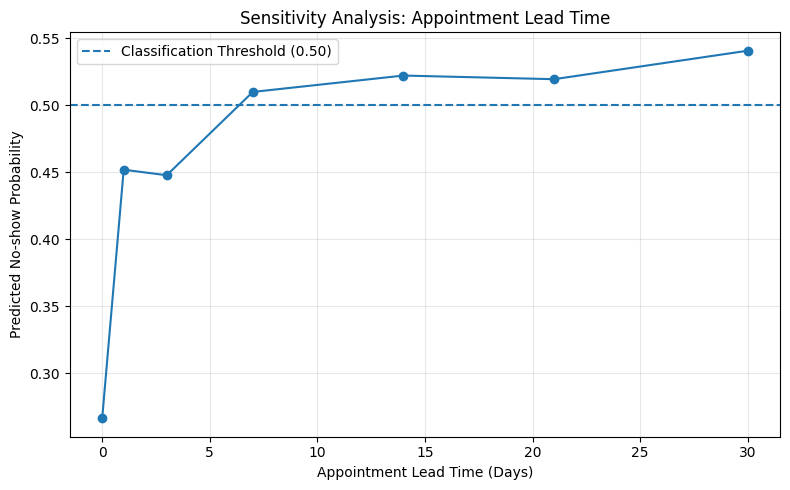

In [48]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.plot(
    sensitivity_df["Appointment Lead Time (Days)"],
    sensitivity_df["Predicted No-show Probability"],
    marker="o"
)

plt.axhline(
    y=0.5,
    linestyle="--",
    label="Classification Threshold (0.50)"
)

plt.xlabel("Appointment Lead Time (Days)")
plt.ylabel("Predicted No-show Probability")
plt.title("Sensitivity Analysis: Appointment Lead Time")
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [49]:
import joblib
import os

model_filename = "upth_no_show_random_forest.joblib"

joblib.dump(tuned_rf_pipeline, model_filename)

print("MODEL SERIALIZATION COMPLETED!")
print("File:", model_filename)
print("File exists:", os.path.exists(model_filename))
print(
    "File size:",
    round(os.path.getsize(model_filename) / (1024 * 1024), 2),
    "MB"
)

MODEL SERIALIZATION COMPLETED!
File: upth_no_show_random_forest.joblib
File exists: True
File size: 86.11 MB


In [50]:
api_code = '''
from fastapi import FastAPI
from pydantic import BaseModel
import pandas as pd
import joblib

app = FastAPI(
    title="UPTH No-Show Prediction API",
    description="API prototype for predicting outpatient appointment no-show risk.",
    version="1.0"
)

model = joblib.load("upth_no_show_random_forest.joblib")


class AppointmentInput(BaseModel):
    Gender: str
    Age: int
    Neighbourhood: str
    Scholarship: int
    Hipertension: int
    Diabetes: int
    Alcoholism: int
    Handcap: int
    SMS_received: int
    AppointmentLeadTime: int
    ScheduledDayOfWeek: int
    AppointmentDayOfWeek: int
    ScheduledHour: int


@app.get("/")
def home():
    return {
        "message": "UPTH No-Show Prediction API",
        "status": "running"
    }


@app.post("/predict")
def predict(data: AppointmentInput):

    input_df = pd.DataFrame([data.model_dump()])

    probability = float(
        model.predict_proba(input_df)[0, 1]
    )

    prediction = int(probability >= 0.5)

    return {
        "prediction": prediction,
        "predicted_outcome":
            "No-show" if prediction == 1 else "Attend",
        "no_show_probability": round(probability, 4),
        "decision_support_notice":
            "Prediction is for planning and reminder support only; "
            "it must not be used to automatically cancel or deny care."
    }
'''

with open("app.py", "w") as f:
    f.write(api_code)

print("FASTAPI APPLICATION CREATED!")
print("File: app.py")

FASTAPI APPLICATION CREATED!
File: app.py


In [51]:
from fastapi.testclient import TestClient
from app import app

client = TestClient(app)

# Test the home endpoint
home_response = client.get("/")

print("HOME ENDPOINT TEST")
print("------------------")
print("Status code:", home_response.status_code)
print("Response:", home_response.json())

# Example appointment using valid model fields
test_appointment = {
    "Gender": "F",
    "Age": 35,
    "Neighbourhood": "JARDIM DA PENHA",
    "Scholarship": 0,
    "Hipertension": 0,
    "Diabetes": 0,
    "Alcoholism": 0,
    "Handcap": 0,
    "SMS_received": 1,
    "AppointmentLeadTime": 7,
    "ScheduledDayOfWeek": 1,
    "AppointmentDayOfWeek": 2,
    "ScheduledHour": 10
}

prediction_response = client.post(
    "/predict",
    json=test_appointment
)

print("\nPREDICT ENDPOINT TEST")
print("---------------------")
print("Status code:", prediction_response.status_code)
print("Response:", prediction_response.json())

HOME ENDPOINT TEST
------------------
Status code: 200
Response: {'message': 'UPTH No-Show Prediction API', 'status': 'running'}

PREDICT ENDPOINT TEST
---------------------
Status code: 200
Response: {'prediction': 0, 'predicted_outcome': 'Attend', 'no_show_probability': 0.4155, 'decision_support_notice': 'Prediction is for planning and reminder support only; it must not be used to automatically cancel or deny care.'}
